Successfully loaded 16 files across 4 target concentration levels.


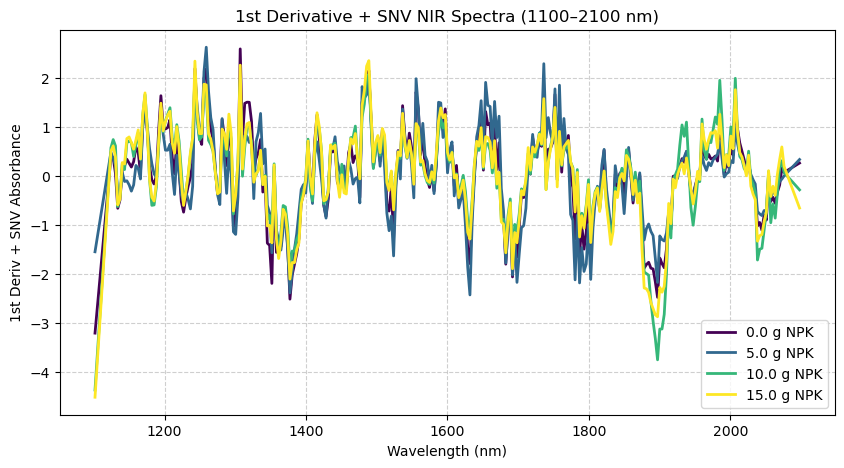


PLSR RESULTS (1st Deriv + SNV) (N = 16 samples)
Calibration R²   (R²_cal)  : 0.8419
Calibration RMSE (RMSEC)   : 2.2225 g
Validation R²    (R²_cv)   : 0.4495
Validation RMSE  (RMSECV)  : 4.1478 g

Individual Sample Validation Errors:
File: 0g_NPK_15ml_0_ang.txt     | Actual:  0.0g | Predicted:  8.04g | Error: 8.04g <--- OUTLIER
File: 0g_NPK_15ml_180_ang.txt   | Actual:  0.0g | Predicted:  2.25g | Error: 2.25g
File: 0g_NPK_15ml_270_ang.txt   | Actual:  0.0g | Predicted:  3.33g | Error: 3.33g <--- OUTLIER
File: 0g_NPK_15ml_90_ang.txt    | Actual:  0.0g | Predicted:  9.06g | Error: 9.06g <--- OUTLIER
File: 10g_NPK_15ml_0_ang.txt    | Actual: 10.0g | Predicted:  2.23g | Error: 7.77g <--- OUTLIER
File: 10g_NPK_15ml_180_ang.txt  | Actual: 10.0g | Predicted:  9.43g | Error: 0.57g
File: 10g_NPK_15ml_270_ang.txt  | Actual: 10.0g | Predicted: 13.05g | Error: 3.05g <--- OUTLIER
File: 10g_NPK_15ml_90_ang.txt   | Actual: 10.0g | Predicted: 10.18g | Error: 0.18g
File: 15g_NPK_15ml_0_ang.txt    | Ac

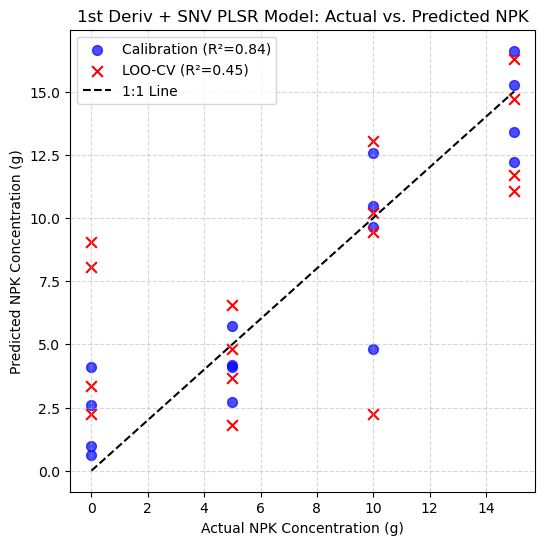

In [6]:
import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import LeaveOneOut

# ==========================================
# 1. HELPER FUNCTIONS FOR PREPROCESSING
# ==========================================
def apply_snv(X_data):
    """
    Standard Normal Variate (SNV) transformation.
    Normalizes each individual spectrum to zero mean and unit variance.
    """
    X_snv = np.zeros_like(X_data)
    for i in range(X_data.shape[0]):
        X_snv[i] = (X_data[i] - np.mean(X_data[i])) / np.std(X_data[i])
    return X_snv

# ==========================================
# 2. LOAD & PARSE ALL 16 SPECTRA
# ==========================================
DATA_FOLDER = "."  # Folder containing your 16 NPK .txt files

file_paths = glob.glob(os.path.join(DATA_FOLDER, "*.txt"))

wavelengths = None
raw_absorbance_list = []
labels = []
filenames = []

for filepath in file_paths:
    fname = os.path.basename(filepath)
    fname_lower = fname.lower()
    
    if 'control' in fname_lower or 'blank' in fname_lower:
        conc = 0.0
    else:
        match = re.search(r'(\d+(?:\.\d+)?)\s*g', fname_lower)
        if match:
            conc = float(match.group(1))
        else:
            print(f"Skipping unmapped file: {fname}")
            continue
    
    try:
        data = pd.read_csv(filepath, sep=r'\s+', skiprows=14, header=None, comment='>')
        data = data.dropna().apply(pd.to_numeric, errors='coerce').dropna()
    except Exception:
        data = np.loadtxt(filepath, skiprows=17)
    
    wl = data.iloc[:, 0].values if isinstance(data, pd.DataFrame) else data[:, 0]
    ref = data.iloc[:, 1].values if isinstance(data, pd.DataFrame) else data[:, 1]
    
    # Mask to optimal InGaAs NIR band (1100 nm - 2100 nm)
    mask = (wl >= 1100) & (wl <= 2100)
    
    if wavelengths is None:
        wavelengths = wl[mask]
        
    # Convert Reflection (%) to Absorbance: A = log10(100 / R)
    ref_clipped = np.clip(ref[mask], 0.01, 100.0)
    abs_spectrum = np.log10(100.0 / ref_clipped)
    
    raw_absorbance_list.append(abs_spectrum)
    labels.append(conc)
    filenames.append(fname)

X_raw = np.array(raw_absorbance_list)
y = np.array(labels)

print(f"Successfully loaded {len(y)} files across {len(set(y))} target concentration levels.")

# ==========================================
# 3. ADVANCED PREPROCESSING PIPELINE
# ==========================================
# Step A: 1st Derivative + Savitzky-Golay (Window: 15, Poly: 2, Deriv: 1)
# Eliminates baseline offsets while highlighting chemical absorption slopes
X_deriv = np.array([savgol_filter(spec, window_length=15, polyorder=2, deriv=1) for spec in X_raw])

# Step B: Standard Normal Variate (SNV) transformation
X = apply_snv(X_deriv)

# Plot Preprocessed Mean Spectra
plt.figure(figsize=(10, 5))
unique_levels = sorted(list(set(y)))
colors = plt.cm.viridis(np.linspace(0, 1, len(unique_levels)))

for idx, level in enumerate(unique_levels):
    mask = y == level
    mean_spectrum = np.mean(X[mask], axis=0)
    plt.plot(wavelengths, mean_spectrum, label=f"{level} g NPK", color=colors[idx], linewidth=2)

plt.xlabel("Wavelength (nm)")
plt.ylabel("1st Deriv + SNV Absorbance")
plt.title("1st Derivative + SNV NIR Spectra (1100–2100 nm)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# ==========================================
# 4. PLS REGRESSION & LOO CROSS-VALIDATION
# ==========================================
n_components = 2
pls = PLSRegression(n_components=n_components)

# Calibration Model
pls.fit(X, y)
y_cal = pls.predict(X).ravel()
r2_cal = r2_score(y, y_cal)
rmsec = np.sqrt(mean_squared_error(y, y_cal))

# Leave-One-Out Cross-Validation (LOOCV)
loo = LeaveOneOut()
y_cv = np.zeros_like(y)

for train_idx, test_idx in loo.split(X):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    model_cv = PLSRegression(n_components=n_components)
    model_cv.fit(X_train, y_train)
    y_cv[test_idx] = model_cv.predict(X_test).ravel()

r2_cv = r2_score(y, y_cv)
rmsecv = np.sqrt(mean_squared_error(y, y_cv))

# Output Performance Metrics
print("\n" + "="*40)
print(f"PLSR RESULTS (1st Deriv + SNV) (N = {len(y)} samples)")
print("="*40)
print(f"Calibration R²   (R²_cal)  : {r2_cal:.4f}")
print(f"Calibration RMSE (RMSEC)   : {rmsec:.4f} g")
print(f"Validation R²    (R²_cv)   : {r2_cv:.4f}")
print(f"Validation RMSE  (RMSECV)  : {rmsecv:.4f} g")
print("="*40)

# Identify individual sample prediction errors
print("\nIndividual Sample Validation Errors:")
for fname, actual, pred in zip(filenames, y, y_cv):
    err = abs(actual - pred)
    flag = " <--- OUTLIER" if err > 3.0 else ""
    print(f"File: {fname:<25} | Actual: {actual:>4.1f}g | Predicted: {pred:>5.2f}g | Error: {err:>4.2f}g{flag}")

# Scatter Plot: Actual vs Predicted
plt.figure(figsize=(6, 6))
plt.scatter(y, y_cal, color='blue', label=f'Calibration (R²={r2_cal:.2f})', alpha=0.7, s=50)
plt.scatter(y, y_cv, color='red', marker='x', label=f'LOO-CV (R²={r2_cv:.2f})', s=60)
plt.plot([min(y), max(y)], [min(y), max(y)], 'k--', label='1:1 Line')

plt.xlabel("Actual NPK Concentration (g)")
plt.ylabel("Predicted NPK Concentration (g)")
plt.title("1st Deriv + SNV PLSR Model: Actual vs. Predicted NPK")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


CLEANED PLSR RESULTS (N = 12 samples)
Calibration R²   (R²_cal)  : 0.8670
Calibration RMSE (RMSEC)   : 2.0388 g
Validation R²    (R²_cv)   : 0.6882
Validation RMSE  (RMSECV)  : 3.1213 g


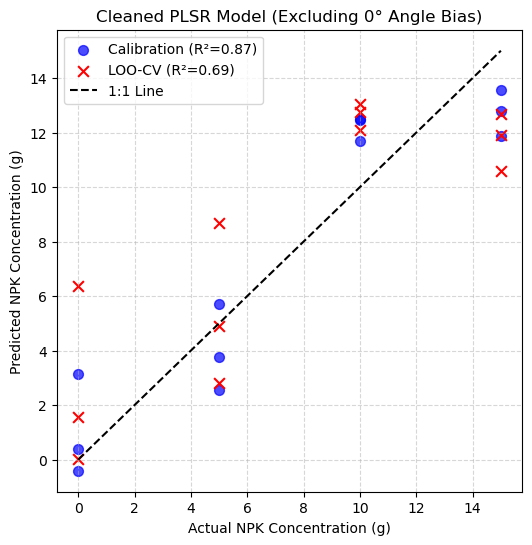

In [7]:
import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import LeaveOneOut

def apply_snv(X_data):
    X_snv = np.zeros_like(X_data)
    for i in range(X_data.shape[0]):
        X_snv[i] = (X_data[i] - np.mean(X_data[i])) / np.std(X_data[i])
    return X_snv

DATA_FOLDER = "."
file_paths = glob.glob(os.path.join(DATA_FOLDER, "*.txt"))

wavelengths = None
raw_absorbance_list = []
labels = []
filenames = []

for filepath in file_paths:
    fname = os.path.basename(filepath)
    fname_lower = fname.lower()
    
    # 1. EXCLUDE BIASED 0-DEGREE ROTATION ANGLE
    if '_0_ang' in fname_lower:
        continue
        
    if 'control' in fname_lower or 'blank' in fname_lower:
        conc = 0.0
    else:
        match = re.search(r'(\d+(?:\.\d+)?)\s*g', fname_lower)
        if match:
            conc = float(match.group(1))
        else:
            continue
    
    try:
        data = pd.read_csv(filepath, sep=r'\s+', skiprows=14, header=None, comment='>')
        data = data.dropna().apply(pd.to_numeric, errors='coerce').dropna()
    except Exception:
        data = np.loadtxt(filepath, skiprows=17)
    
    wl = data.iloc[:, 0].values if isinstance(data, pd.DataFrame) else data[:, 0]
    ref = data.iloc[:, 1].values if isinstance(data, pd.DataFrame) else data[:, 1]
    
    mask = (wl >= 1100) & (wl <= 2100)
    if wavelengths is None:
        wavelengths = wl[mask]
        
    ref_clipped = np.clip(ref[mask], 0.01, 100.0)
    abs_spectrum = np.log10(100.0 / ref_clipped)
    
    raw_absorbance_list.append(abs_spectrum)
    labels.append(conc)
    filenames.append(fname)

X_raw = np.array(raw_absorbance_list)
y = np.array(labels)

# Preprocessing: SG Filter + SNV
X_sg = np.array([savgol_filter(spec, window_length=15, polyorder=2) for spec in X_raw])
X = apply_snv(X_sg)

# PLSR & LOOCV
n_components = 2
pls = PLSRegression(n_components=n_components)
pls.fit(X, y)
y_cal = pls.predict(X).ravel()
r2_cal = r2_score(y, y_cal)
rmsec = np.sqrt(mean_squared_error(y, y_cal))

loo = LeaveOneOut()
y_cv = np.zeros_like(y)
for train_idx, test_idx in loo.split(X):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    model_cv = PLSRegression(n_components=n_components)
    model_cv.fit(X_train, y_train)
    y_cv[test_idx] = model_cv.predict(X_test).ravel()

r2_cv = r2_score(y, y_cv)
rmsecv = np.sqrt(mean_squared_error(y, y_cv))

print("\n" + "="*40)
print(f"CLEANED PLSR RESULTS (N = {len(y)} samples)")
print("="*40)
print(f"Calibration R²   (R²_cal)  : {r2_cal:.4f}")
print(f"Calibration RMSE (RMSEC)   : {rmsec:.4f} g")
print(f"Validation R²    (R²_cv)   : {r2_cv:.4f}")
print(f"Validation RMSE  (RMSECV)  : {rmsecv:.4f} g")
print("="*40)

# Scatter Plot
plt.figure(figsize=(6, 6))
plt.scatter(y, y_cal, color='blue', label=f'Calibration (R²={r2_cal:.2f})', alpha=0.7, s=50)
plt.scatter(y, y_cv, color='red', marker='x', label=f'LOO-CV (R²={r2_cv:.2f})', s=60)
plt.plot([min(y), max(y)], [min(y), max(y)], 'k--', label='1:1 Line')
plt.xlabel("Actual NPK Concentration (g)")
plt.ylabel("Predicted NPK Concentration (g)")
plt.title("Cleaned PLSR Model (Excluding 0° Angle Bias)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

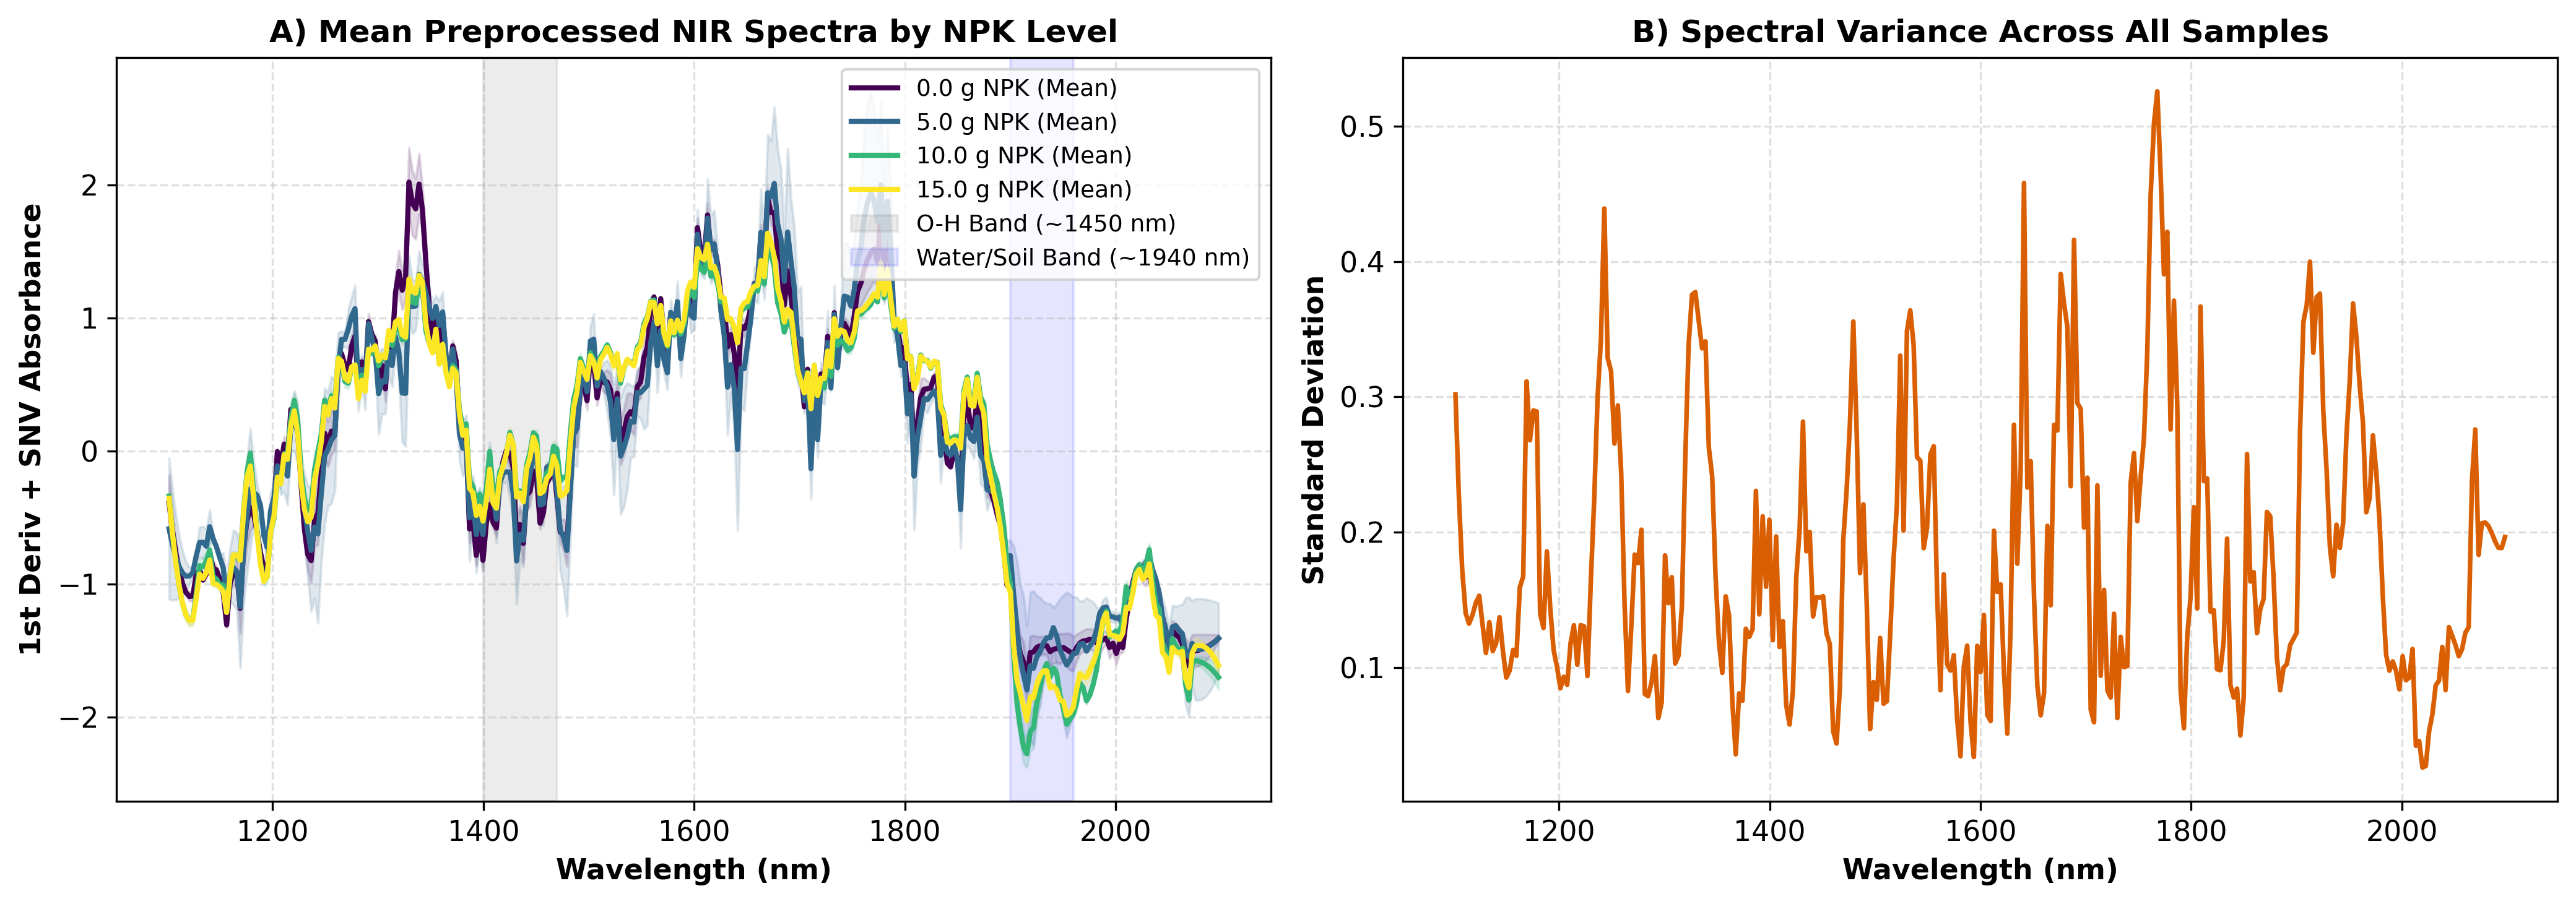

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Set figure formatting for research presentation
plt.rcParams.update({'font.size': 11, 'font.family': 'sans-serif'})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), dpi=300)

unique_levels = sorted(list(set(y)))
colors = ['#440154', '#31688e', '#35b779', '#fde725']  # Distinct Viridis palette

# ---------------------------------------------------------
# PANEL A: Mean Spectra per Concentration Level
# ---------------------------------------------------------
for idx, level in enumerate(unique_levels):
    mask = (y == level)
    mean_spec = np.mean(X[mask], axis=0)
    std_spec = np.std(X[mask], axis=0)
    
    # Plot mean line
    ax1.plot(wavelengths, mean_spec, label=f"{level:.1f} g NPK (Mean)", 
             color=colors[idx], linewidth=2.0)
    
    # Optional: Light fill for 1 std dev variability across rotational angles
    ax1.fill_between(wavelengths, mean_spec - std_spec, mean_spec + std_spec, 
                     color=colors[idx], alpha=0.15)

# Highlight prominent absorption regions
ax1.axvspan(1400, 1470, color='gray', alpha=0.15, label='O-H Band (~1450 nm)')
ax1.axvspan(1900, 1960, color='blue', alpha=0.10, label='Water/Soil Band (~1940 nm)')

ax1.set_xlabel("Wavelength (nm)", fontweight='bold')
ax1.set_ylabel("1st Deriv + SNV Absorbance", fontweight='bold')
ax1.set_title("A) Mean Preprocessed NIR Spectra by NPK Level", fontsize=12, fontweight='bold')
ax1.legend(loc='upper right', frameon=True, fontsize=9)
ax1.grid(True, linestyle='--', alpha=0.4)

# ---------------------------------------------------------
# PANEL B: Spectral Standard Deviation (Noise / Variability)
# ---------------------------------------------------------
overall_std = np.std(X, axis=0)
ax2.plot(wavelengths, overall_std, color='#d95f02', linewidth=1.8)
ax2.set_xlabel("Wavelength (nm)", fontweight='bold')
ax2.set_ylabel("Standard Deviation", fontweight='bold')
ax2.set_title("B) Spectral Variance Across All Samples", fontsize=12, fontweight='bold')
ax2.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig("NPK_NIR_Spectra_Publication_Ready.png", dpi=300, bbox_inches='tight')
plt.show()

Successfully loaded 12 clean files (excluding 0-degree bias).


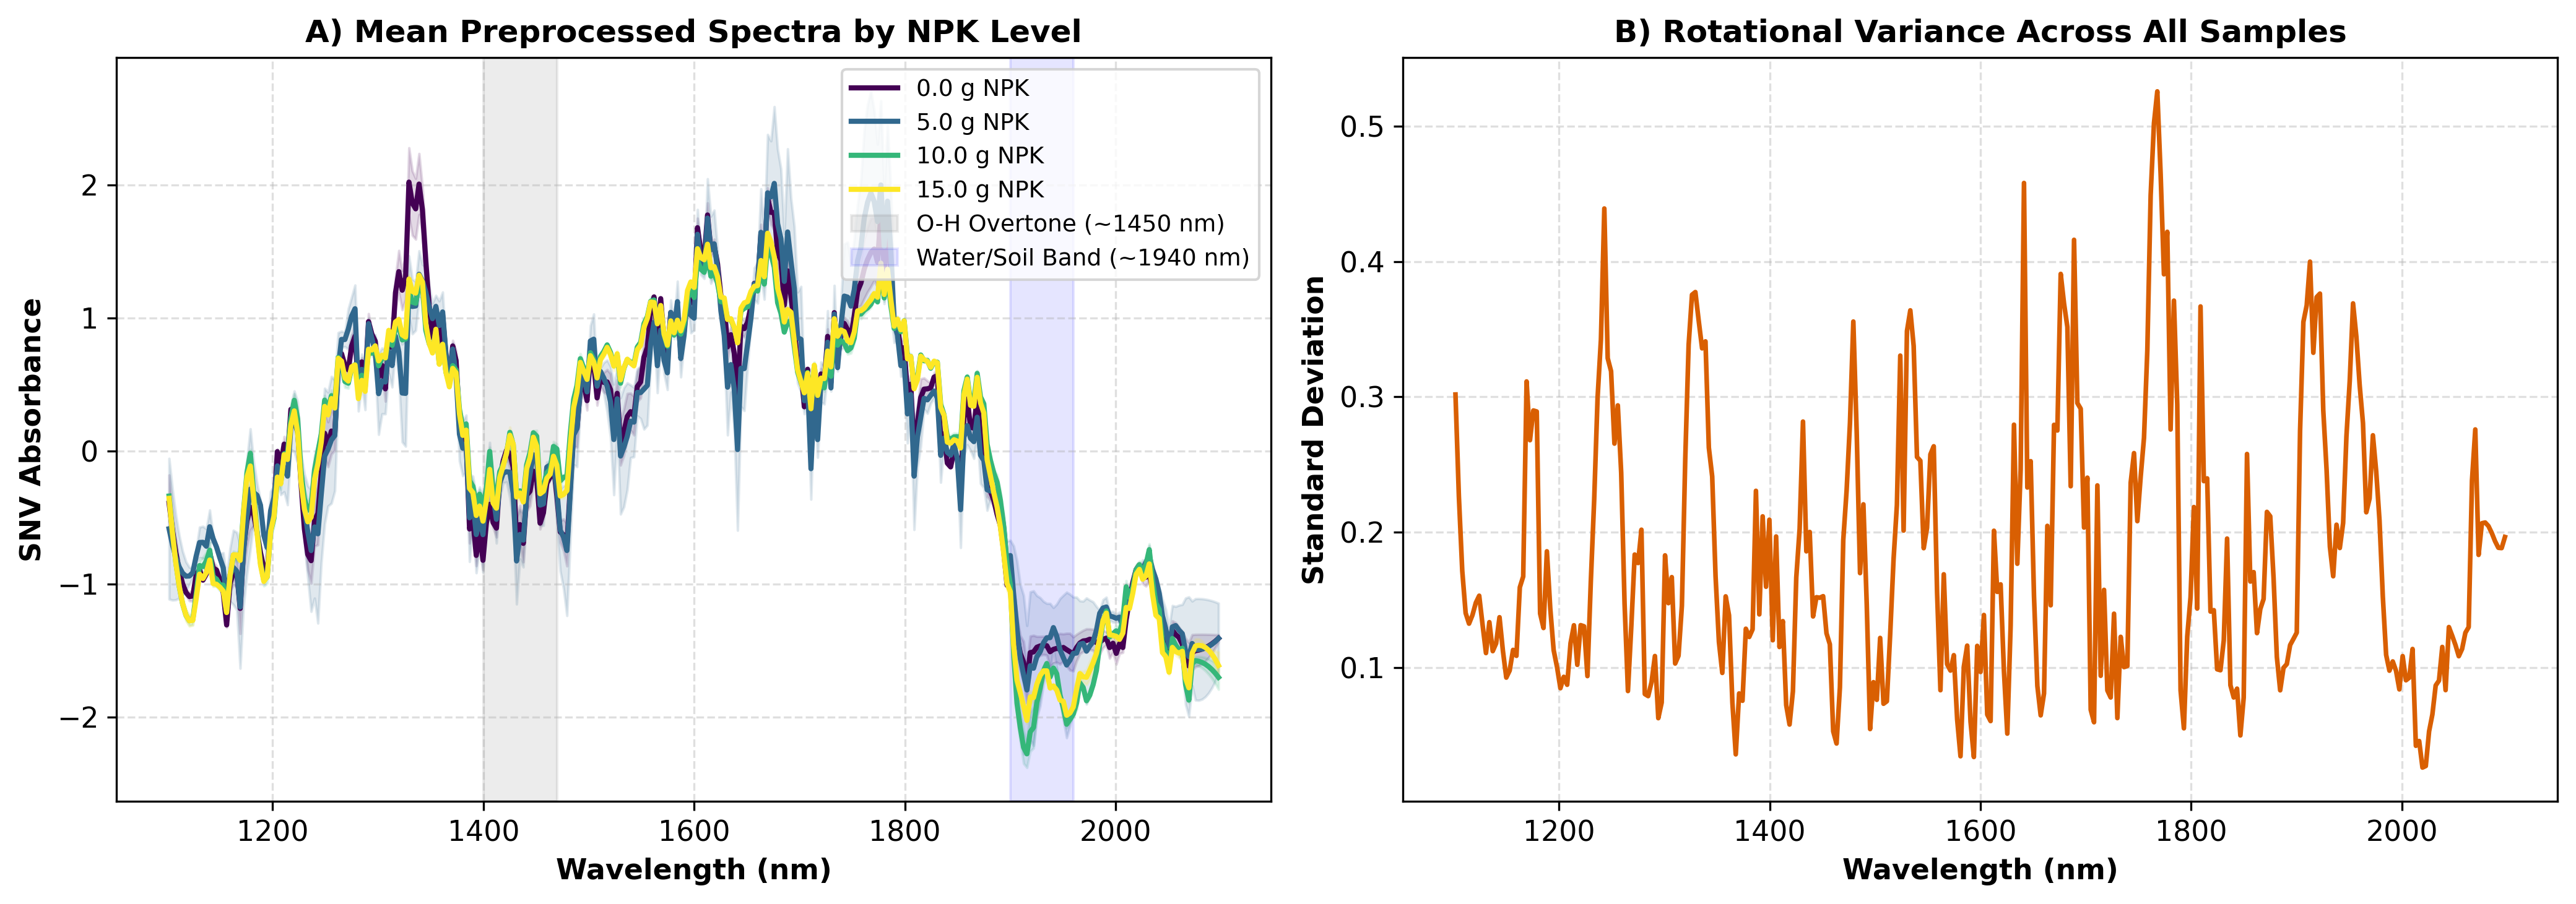


FINAL PLSR PERFORMANCE METRICS (N = 12)
Calibration R²   (R²_cal)  : 0.8670
Calibration RMSE (RMSEC)   : 2.0388 g
Validation R²    (R²_cv)   : 0.6882
Validation RMSE  (RMSECV)  : 3.1213 g


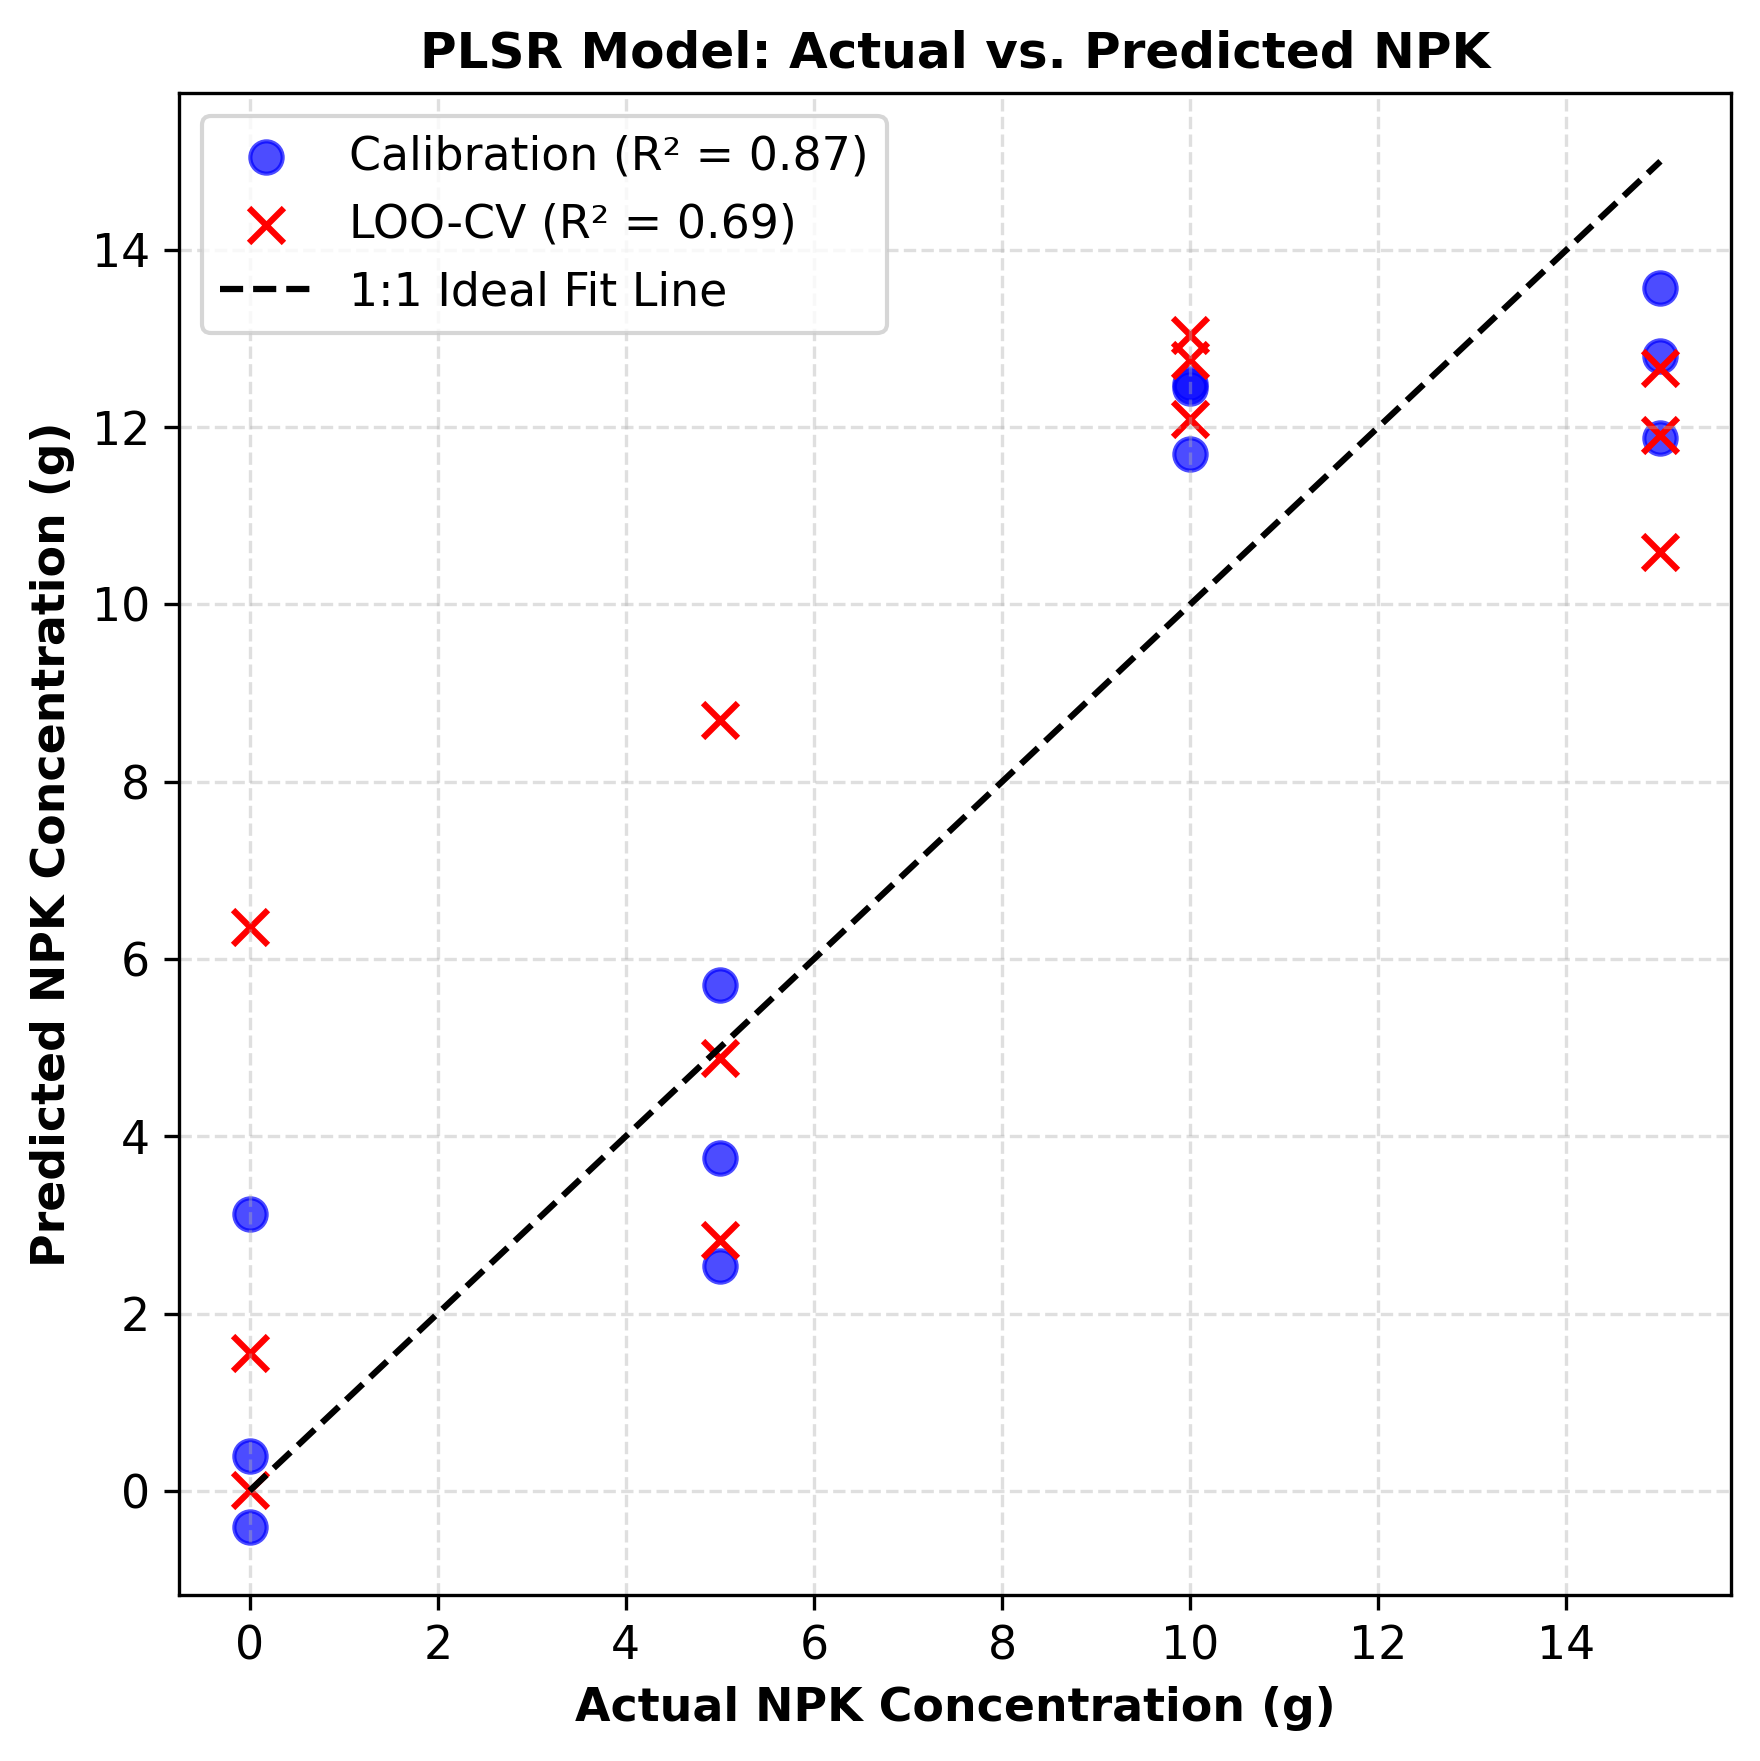

In [9]:
import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import LeaveOneOut

# Adjust global matplotlib parameters for clean report formatting
plt.rcParams.update({'font.size': 11, 'font.family': 'sans-serif'})

# ==========================================
# 1. PREPROCESSING HELPER FUNCTIONS
# ==========================================
def apply_snv(X_data):
    """
    Standard Normal Variate (SNV) transformation.
    Normalizes each spectrum to zero mean and unit variance.
    """
    X_snv = np.zeros_like(X_data)
    for i in range(X_data.shape[0]):
        X_snv[i] = (X_data[i] - np.mean(X_data[i])) / np.std(X_data[i])
    return X_snv

# ==========================================
# 2. DATA LOADING & PARSING PIPELINE
# ==========================================
DATA_FOLDER = "."  # Folder containing your 16 NPK .txt files
file_paths = glob.glob(os.path.join(DATA_FOLDER, "*.txt"))

wavelengths = None
raw_absorbance_list = []
labels = []
filenames = []

for filepath in file_paths:
    fname = os.path.basename(filepath)
    fname_lower = fname.lower()
    
    # Exclude the 0-degree rotational angle due to systematic optical bias
    if '_0_ang' in fname_lower:
        continue
        
    # Map target concentrations (0g, 5g, 10g, 15g)
    if 'control' in fname_lower or 'blank' in fname_lower:
        conc = 0.0
    else:
        match = re.search(r'(\d+(?:\.\d+)?)\s*g', fname_lower)
        if match:
            conc = float(match.group(1))
        else:
            continue
    
    # Parse OceanView files
    try:
        data = pd.read_csv(filepath, sep=r'\s+', skiprows=14, header=None, comment='>')
        data = data.dropna().apply(pd.to_numeric, errors='coerce').dropna()
    except Exception:
        data = np.loadtxt(filepath, skiprows=17)
    
    wl = data.iloc[:, 0].values if isinstance(data, pd.DataFrame) else data[:, 0]
    ref = data.iloc[:, 1].values if isinstance(data, pd.DataFrame) else data[:, 1]
    
    # Mask to optimal InGaAs detector window (1100 nm - 2100 nm)
    mask = (wl >= 1100) & (wl <= 2100)
    
    if wavelengths is None:
        wavelengths = wl[mask]
        
    # Convert Reflection (%) to Absorbance: A = log10(100 / R)
    ref_clipped = np.clip(ref[mask], 0.01, 100.0)
    abs_spectrum = np.log10(100.0 / ref_clipped)
    
    raw_absorbance_list.append(abs_spectrum)
    labels.append(conc)
    filenames.append(fname)

X_raw = np.array(raw_absorbance_list)
y = np.array(labels)

print(f"Successfully loaded {len(y)} clean files (excluding 0-degree bias).")

# ==========================================
# 3. SPECTRAL PREPROCESSING (SG + SNV)
# ==========================================
# Savitzky-Golay smoothing (Window: 15, Poly: 2) + SNV Transformation
X_sg = np.array([savgol_filter(spec, window_length=15, polyorder=2) for spec in X_raw])
X = apply_snv(X_sg)

# ==========================================
# 4. SUPERVISOR-READY SPECTRAL PLOTS
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), dpi=300)
unique_levels = sorted(list(set(y)))
colors = ['#440154', '#31688e', '#35b779', '#fde725']

# Panel A: Class Means with Variability Bands
for idx, level in enumerate(unique_levels):
    mask = (y == level)
    mean_spec = np.mean(X[mask], axis=0)
    std_spec = np.std(X[mask], axis=0)
    
    ax1.plot(wavelengths, mean_spec, label=f"{level:.1f} g NPK", color=colors[idx], linewidth=2.0)
    ax1.fill_between(wavelengths, mean_spec - std_spec, mean_spec + std_spec, color=colors[idx], alpha=0.15)

ax1.axvspan(1400, 1470, color='gray', alpha=0.15, label='O-H Overtone (~1450 nm)')
ax1.axvspan(1900, 1960, color='blue', alpha=0.10, label='Water/Soil Band (~1940 nm)')
ax1.set_xlabel("Wavelength (nm)", fontweight='bold')
ax1.set_ylabel("SNV Absorbance", fontweight='bold')
ax1.set_title("A) Mean Preprocessed Spectra by NPK Level", fontsize=12, fontweight='bold')
ax1.legend(loc='upper right', frameon=True, fontsize=9)
ax1.grid(True, linestyle='--', alpha=0.4)

# Panel B: Spectral Standard Deviation
overall_std = np.std(X, axis=0)
ax2.plot(wavelengths, overall_std, color='#d95f02', linewidth=1.8)
ax2.set_xlabel("Wavelength (nm)", fontweight='bold')
ax2.set_ylabel("Standard Deviation", fontweight='bold')
ax2.set_title("B) Rotational Variance Across All Samples", fontsize=12, fontweight='bold')
ax2.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig("NPK_NIR_Spectra_Clean.png", dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# 5. PLS REGRESSION & LOO CROSS-VALIDATION
# ==========================================
n_components = 2
pls = PLSRegression(n_components=n_components)

# Model Calibration
pls.fit(X, y)
y_cal = pls.predict(X).ravel()
r2_cal = r2_score(y, y_cal)
rmsec = np.sqrt(mean_squared_error(y, y_cal))

# Leave-One-Out Cross-Validation (LOOCV)
loo = LeaveOneOut()
y_cv = np.zeros_like(y)

for train_idx, test_idx in loo.split(X):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    model_cv = PLSRegression(n_components=n_components)
    model_cv.fit(X_train, y_train)
    y_cv[test_idx] = model_cv.predict(X_test).ravel()

r2_cv = r2_score(y, y_cv)
rmsecv = np.sqrt(mean_squared_error(y, y_cv))

print("\n" + "="*45)
print(f"FINAL PLSR PERFORMANCE METRICS (N = {len(y)})")
print("="*45)
print(f"Calibration R²   (R²_cal)  : {r2_cal:.4f}")
print(f"Calibration RMSE (RMSEC)   : {rmsec:.4f} g")
print(f"Validation R²    (R²_cv)   : {r2_cv:.4f}")
print(f"Validation RMSE  (RMSECV)  : {rmsecv:.4f} g")
print("="*45)

# ==========================================
# 6. ACTUAL VS PREDICTED SCATTER PLOT
# ==========================================
plt.figure(figsize=(6, 6), dpi=300)
plt.scatter(y, y_cal, color='blue', label=f'Calibration (R² = {r2_cal:.2f})', alpha=0.7, s=60)
plt.scatter(y, y_cv, color='red', marker='x', label=f'LOO-CV (R² = {r2_cv:.2f})', s=70)
plt.plot([min(y), max(y)], [min(y), max(y)], 'k--', label='1:1 Ideal Fit Line')

plt.xlabel("Actual NPK Concentration (g)", fontweight='bold')
plt.ylabel("Predicted NPK Concentration (g)", fontweight='bold')
plt.title("PLSR Model: Actual vs. Predicted NPK", fontsize=12, fontweight='bold')
plt.legend(loc='upper left', frameon=True)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig("NPK_PLSR_Regression_Clean.png", dpi=300, bbox_inches='tight')
plt.show()